In [1]:
import h5py
import numpy as np
import pandas as pd

from config import SIMULATED_DATA_FILE

file_path = SIMULATED_DATA_FILE

rows = []

In [2]:
with h5py.File(file_path, "r") as f:
    rooms = list(f.keys())  # <-- FIX

    for room in rooms:
        grp = f[room]

        room_dim = grp["room_dim"][0]
        receivers = grp["receiver_pos"].shape[0]

        T60 = grp["T60"][0][0]
        alpha = grp["alpha"][0][0]

        L, W, H = room_dim
        volume = L * W * H

        rows.append({
            "room": room,
            "L": L,
            "W": W,
            "H": H,
            "volume": volume,
            "n_receivers": receivers,
            "T60": T60,
            "alpha": alpha
        })

df = pd.DataFrame(rows)
df["room_id"] = df["room"].apply(lambda x: x.split("\\")[-1])
print(df.head())
print(len(df))

                        room     L      W     H      volume  n_receivers  \
0  simulated_RTFs\room_00001  9.77  16.50  1.82  293.393100         1728   
1  simulated_RTFs\room_00002  6.65   4.14  3.10   85.346100          252   
2  simulated_RTFs\room_00003  9.45   9.94  3.08  289.313640          918   
3  simulated_RTFs\room_00004  7.91   9.88  3.02  236.015416          756   
4  simulated_RTFs\room_00005  7.76  15.84  1.84  226.169856         1260   

      T60  alpha     room_id  
0  0.1253    0.9  room_00001  
1  0.3757    0.3  room_00002  
2  0.2529    0.6  room_00003  
3  0.4799    0.3  room_00004  
4  1.0956    0.1  room_00005  
20000


In [3]:
print(df.describe())

                  L             W             H        volume   n_receivers  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       7.256986      9.313827      2.553468    164.211196    662.690700   
std        1.644505      3.906269      0.564646     69.157147    342.118094   
min        3.500000      2.260000      1.500000     49.902309     96.000000   
25%        6.020000      6.170000      2.080000    105.289206    384.000000   
50%        7.340000      8.940000      2.570000    158.580102    612.000000   
75%        8.620000     12.050000      3.040000    220.576242    870.000000   
max       10.000000     20.000000      3.500000    300.470575   2052.000000   

                T60         alpha  
count  20000.000000  20000.000000  
mean       0.483425      0.474250  
std        0.434527      0.304816  
min        0.085700      0.100000  
25%        0.159400      0.100000  
50%        0.281800      0.300000  
75%        0.869350      0.900000  


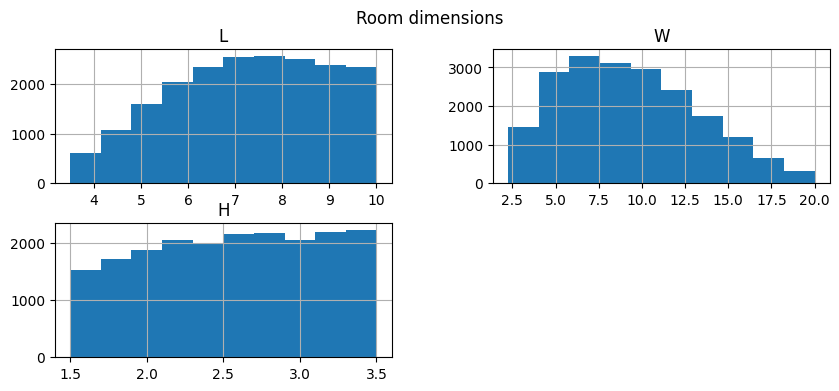

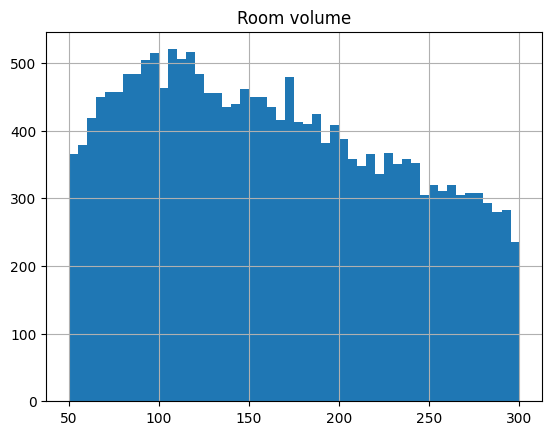

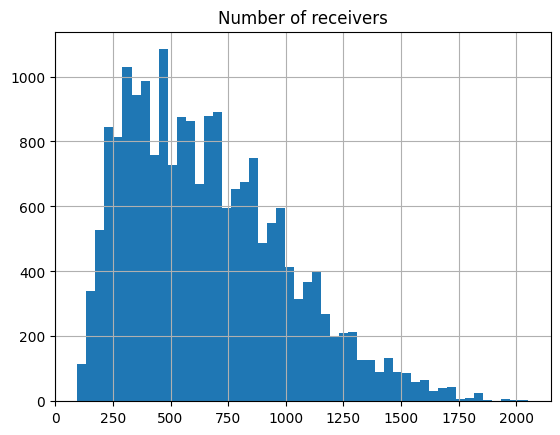

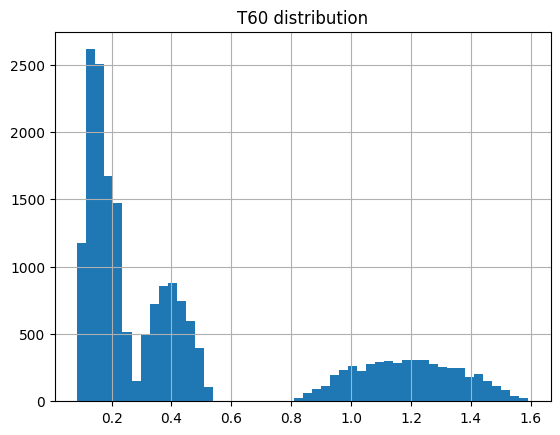

In [4]:
import matplotlib.pyplot as plt

df[["L", "W", "H"]].hist(figsize=(10, 4))
plt.suptitle("Room dimensions")
plt.show()

df["volume"].hist(bins=50)
plt.title("Room volume")
plt.show()

df["n_receivers"].hist(bins=50)
plt.title("Number of receivers")
plt.show()

df["T60"].hist(bins=50)
plt.title("T60 distribution")
plt.show()

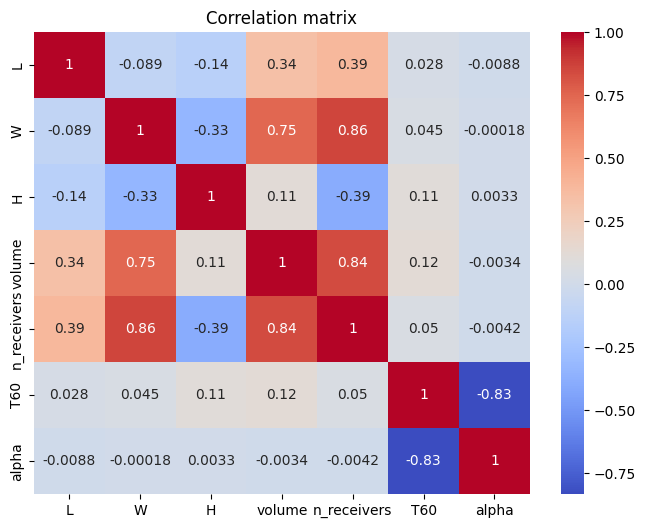

In [5]:
import seaborn as sns

corr = df[["L","W","H","volume","n_receivers","T60","alpha"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

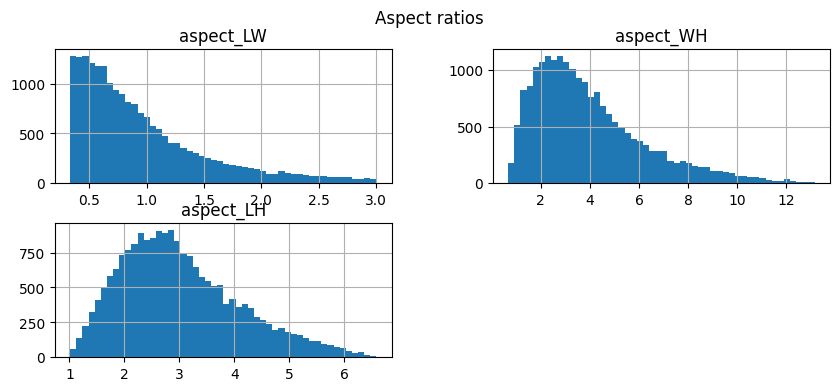

In [6]:
df["aspect_LW"] = df["L"] / df["W"]
df["aspect_WH"] = df["W"] / df["H"]
df["aspect_LH"] = df["L"] / df["H"]

df[["aspect_LW", "aspect_WH", "aspect_LH"]].hist(bins=50, figsize=(10,4))
plt.suptitle("Aspect ratios")
plt.show()

<Axes: xlabel='T60', ylabel='Count'>

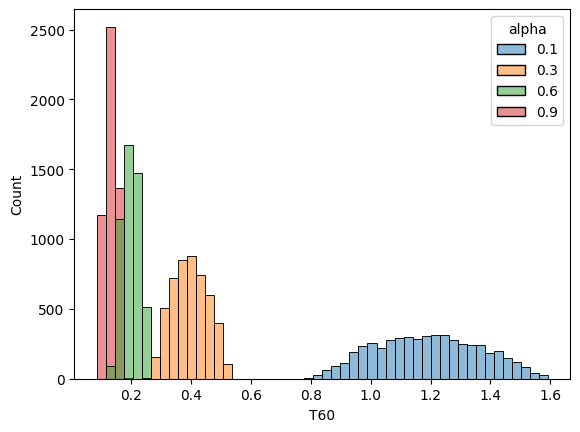

In [7]:
import seaborn as sns

sns.histplot(data=df, x="T60", hue="alpha", bins=50, palette="tab10")

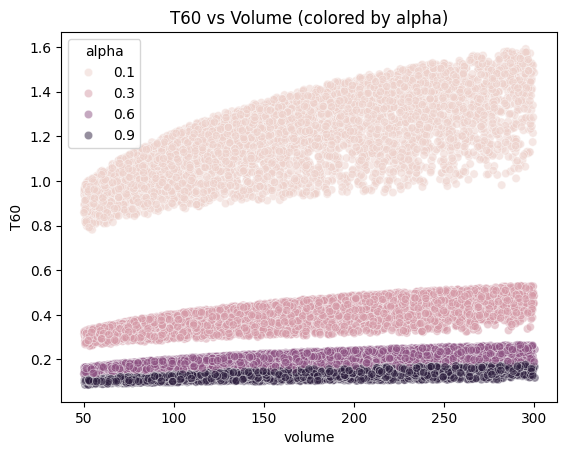

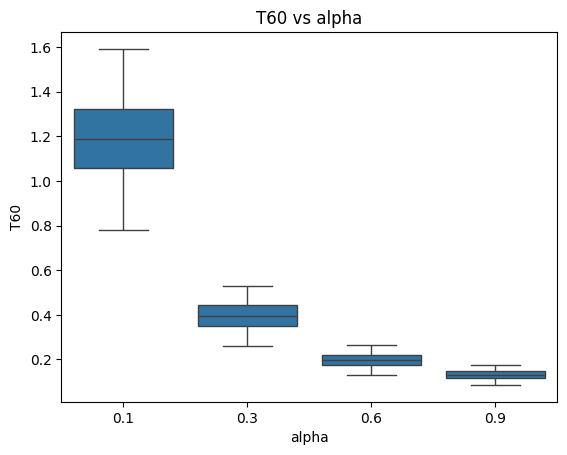

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="volume", y="T60", hue="alpha", alpha=0.5)
plt.title("T60 vs Volume (colored by alpha)")
plt.show()

sns.boxplot(data=df, x="alpha", y="T60")
plt.title("T60 vs alpha")
plt.show()

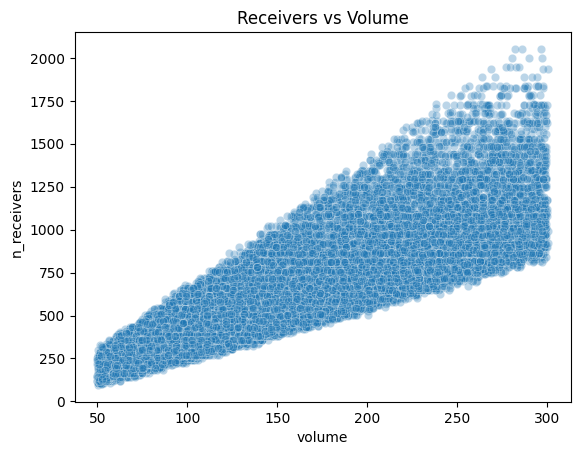

In [9]:
sns.scatterplot(data=df, x="volume", y="n_receivers", alpha=0.3)
plt.title("Receivers vs Volume")
plt.show()

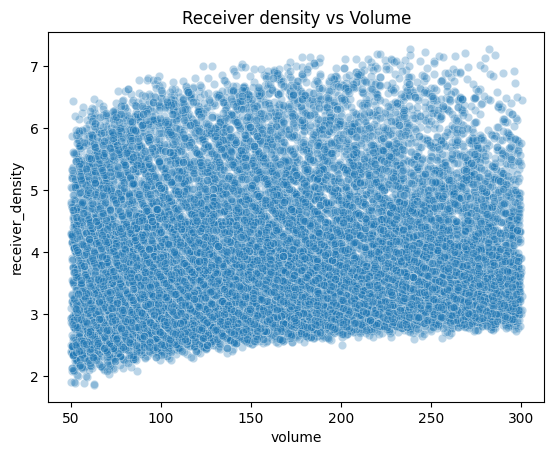

In [10]:
df["receiver_density"] = df["n_receivers"] / df["volume"]

sns.scatterplot(data=df, x="volume", y="receiver_density", alpha=0.3)
plt.title("Receiver density vs Volume")
plt.show()

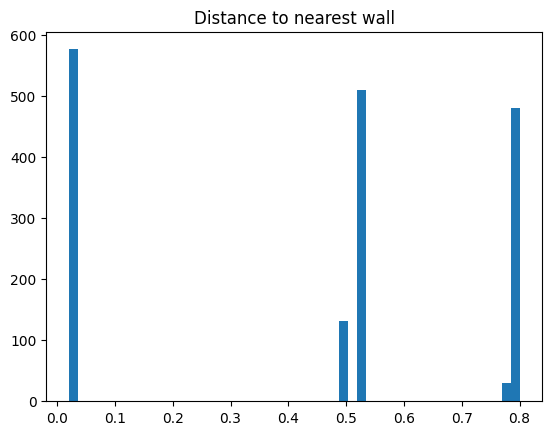

In [11]:
# for one room
room = df["room"].iloc[0]

with h5py.File(file_path, "r") as f:
    grp = f[room]
    pos = grp["receiver_pos"][:]
    dims = grp["room_dim"][0]

dist_to_walls = np.min([
    pos[:,0],
    dims[0] - pos[:,0],
    pos[:,1],
    dims[1] - pos[:,1],
    pos[:,2],
    dims[2] - pos[:,2],
], axis=0)

plt.hist(dist_to_walls, bins=50)
plt.title("Distance to nearest wall")
plt.show()

In [12]:
# checking for duplicates in the data

print(df.duplicated(subset=["L","W","H","alpha"]).sum())

0


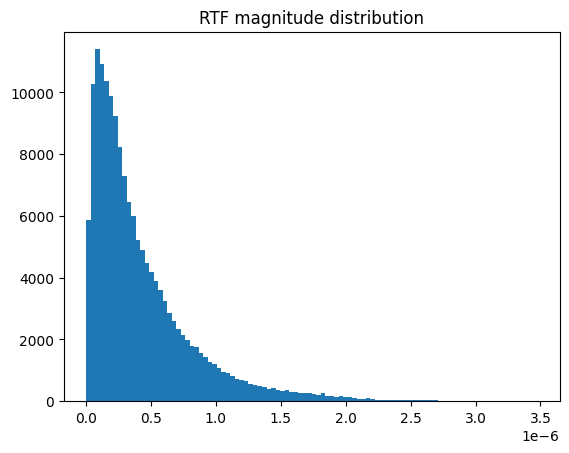

In [13]:
magnitudes = []

with h5py.File(file_path, "r") as f:
    for room in list(df["room"])[:10]:  # sample
        grp = f[room]
        real = grp["RTF_real"][:, :, :50]
        imag = grp["RTF_imag"][:, :, :50]

        mag = np.sqrt(real**2 + imag**2)
        magnitudes.append(mag.flatten())

magnitudes = np.concatenate(magnitudes)

plt.hist(magnitudes, bins=100)
plt.title("RTF magnitude distribution")
plt.show()